57.625 32.0 50.875 51.625
데이터 [[59, 35]] , 판정 결과: 닥스훈트 | P(닥스)=0.83, P(진도)=0.17


C:\Code\PythonProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Code\PythonProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Code\PythonProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Code\PythonProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


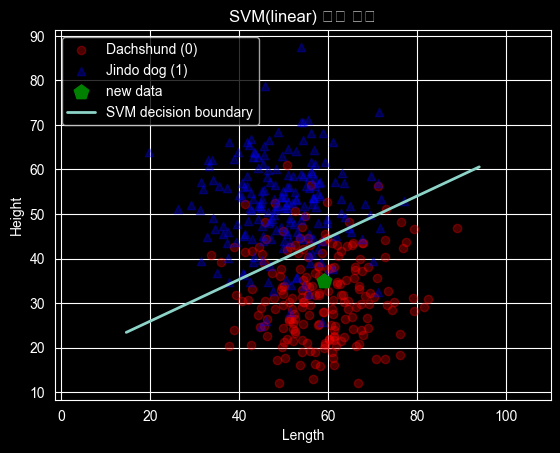

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 닥스훈트(클래스 0) 원본 데이터(8개)
dach_length = np.array([55, 57, 64, 63, 58, 49, 54, 61])
dach_height = np.array([30, 31, 36, 30, 33, 25, 37, 34])

# 진돗개(클래스 1) 원본 데이터(8개)
jin_length  = np.array([56, 47, 56, 46, 49, 53, 52, 48])
jin_height  = np.array([52, 52, 50, 53, 50, 53, 49, 54])

# 평균(랜덤 데이터 생성용)
a = dach_length.mean()
b = dach_height.mean()
c = jin_length.mean()
d = jin_height.mean()
print(a, b, c, d)

# 랜덤 데이터(각 클래스 200개) 생성
dach_length_random = np.random.randn(200) * 10 + a
dach_height_random = np.random.randn(200) * 10 + b
jin_length_random  = np.random.randn(200) * 10 + c
jin_height_random  = np.random.randn(200) * 10 + d

# 새 데이터 (샘플1개, 특성2개)
newdata = np.array([[59, 35]])

# 학습 데이터 만들기 (X)
d_data = np.column_stack((dach_length_random, dach_height_random))
j_data = np.column_stack((jin_length_random,  jin_height_random))
dogs = np.vstack((d_data, j_data))                 # (400,2)

# 라벨 만들기 (y)
labels = np.hstack((
    np.zeros(len(d_data), dtype=int),              # 닥스훈트=0
    np.ones(len(j_data), dtype=int)                # 진돗개=1
))                                                 # (400,)

dog_classes = {0: '닥스훈트', 1: '진돗개'}

# -----------------------------
# SVM 모델 (스케일링 + SVC)
# -----------------------------
# SVM은 거리/스케일에 민감해서 StandardScaler를 같이 쓰는 게 일반적
# kernel='linear' : 직선으로 분리(지금 데이터는 거의 이걸로도 충분)
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1.0, probability=True))  # probability=True -> predict_proba 사용 가능
])

svm.fit(dogs, labels)

# 예측(클래스)
y_pred = svm.predict(newdata)[0]
# 예측(확률)  [P(class0), P(class1)]
y_prob = svm.predict_proba(newdata)[0]

print('데이터', newdata.tolist(),
      ', 판정 결과:', dog_classes[int(y_pred)],
      f"| P(닥스)={y_prob[0]:.2f}, P(진도)={y_prob[1]:.2f}")

# -----------------------------
# 시각화 (데이터 + 새 점)
# -----------------------------
plt.scatter(dach_length_random, dach_height_random, c='r', alpha=0.3, label='Dachshund (0)')
plt.scatter(jin_length_random,  jin_height_random,  c='b', marker='^', alpha=0.3, label='Jindo dog (1)')
plt.scatter(newdata[0, 0], newdata[0, 1], s=120, marker='p', c='g', label='new data')

# (선택) 선형 SVM 결정경계 그리기
# Pipeline이라서 scaler와 svc를 꺼내서 "원래 좌표계"에서 선을 그려야 함
scaler = svm.named_steps["scaler"]
svc = svm.named_steps["svc"]

# x 범위 잡고(원래 좌표계)
x_min = dogs[:, 0].min() - 5
x_max = dogs[:, 0].max() + 5
xs = np.linspace(x_min, x_max, 200)

# 결정경계: w0*x + w1*y + b = 0  ->  y = -(w0*x + b)/w1
# w,b는 "스케일된 공간"의 값이므로, x를 스케일한 뒤 y를 계산하고 다시 역변환 필요
w = svc.coef_[0]          # (2,)
b0 = svc.intercept_[0]

# x를 스케일 공간으로 변환
xs_scaled = (xs - scaler.mean_[0]) / scaler.scale_[0]

# y_scaled 계산
ys_scaled = -(w[0] * xs_scaled + b0) / w[1]

# y를 원래 좌표로 역변환
ys = ys_scaled * scaler.scale_[1] + scaler.mean_[1]

plt.plot(xs, ys, linewidth=2, label='SVM decision boundary')

plt.legend()
plt.axis('equal')
plt.title("SVM(linear) 분류 결과")
plt.xlabel("Length")
plt.ylabel("Height")
plt.show()